In [83]:
import sys
sys.path.insert(1, '/Users/sabina/Desktop/GitHub/ExoMult')
import ExoMult
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.stats import mad_std
import emcee
from scipy import stats
from scipy.special import gamma, factorial
from scipy.stats import norm, uniform, beta, poisson, binom, binned_statistic, anderson_ksamp
from matplotlib.backends.backend_pdf import PdfPages
import multiprocessing as mp
import os
from pympler.tracker import SummaryTracker
import copy
from astropy.table import Table, unique
from astropy.stats import mad_std
os.environ["OMP_NUM_THREADS"] = "1"
import seaborn as sns
import tqdm
import corner

from multiprocessing import Pool


In [2]:
np.random.seed(42)

In [3]:
pMin, pMax = 1.0, 10.0      # days
rMin, rMax = 1.0, 4.0       # Earth radii
FeH_edges = np.array([-0.5, -0.15, 0.15, 0.5])   # bins for the points only
FeHMin, FeHMax = FeH_edges[0], FeH_edges[-1]
b_max = 0.9                 # impact-parameter cut (Zink et al. 2023)
good_flags = ['KP', 'PC']   # known planets + planet candidates (no FP, no LPPC)

In [4]:
planets = pd.read_csv('all_planets_with_abundance_info.csv', dtype={'CAND': str})
stars = pd.read_csv('all_stars_with_abundance_info.csv')

In [5]:
stellar = stars.copy()
stellar.shape

(27390, 60)

In [6]:
cdpp_cols = ['CDPP1', 'CDPP1_5', 'CDPP2', 'CDPP2_5', 'CDPP3', 'CDPP4',
             'CDPP5', 'CDPP6', 'CDPP7', 'CDPP8', 'CDPP9', 'CDPP10']
cdx = np.array([1, 1.5, 2, 2.5, 3, 4, 5, 6, 7, 8, 9, 10])   # hours, taken from Jessie

need = ['Campaign', 'apogee_fe_h', 'apogee_e_fe_h', 'apogee_teff', 'apogee_logg',
        'RUWE', 'Rad', 'Mass', 'limb1', 'limb2'] + cdpp_cols
stellar[need] = stellar[need].where(stellar[need] > -999)   # -999 / -9999 mean "missing"
stellar = stellar[np.isfinite(stellar[need]).all(axis=1)]   # also removes the ~350 stars with inf CDPPs
stellar.shape

(24353, 60)

In [7]:
# removing really noisy targets
stellar = stellar[(stellar[cdpp_cols] > 0).all(axis=1) & (stellar.CDPP8 <= 1200)]
stellar.shape

(22280, 60)

In [8]:
# FGK stars only
stellar = stellar[(stellar.apogee_teff >= 4000) & (stellar.apogee_teff <= 6500)]
stellar.shape

(21603, 60)

In [10]:
# I am not sure with this:
# logg_limit = np.arctan((6300 - stellar.apogee_teff) / 67.172) / 4.671 + 3.876
# stellar = stellar[stellar.apogee_logg >= logg_limit]
# stellar.shape

In [11]:
stellar = stellar[(stellar.RUWE > 0) & (stellar.RUWE < 1.4)]
stellar = stellar[(stellar.Mass > 0) & (stellar.Rad > 0)]
stellar.shape

(17984, 60)

In [12]:
# FeH range
stellar = stellar[(stellar.apogee_fe_h >= FeHMin) & (stellar.apogee_fe_h <= FeHMax) & (stellar.apogee_e_fe_h > 0)]
stellar.shape

(15726, 60)

In [13]:
stellar['EPIC_ID'].duplicated().sum()

0

In [14]:
stellar = stellar.sort_values('EPIC_ID').reset_index(drop=True)
stellar['Campaign'] = stellar['Campaign'].astype(int)
stellar['d_span'] = 80 # days hard coded

In [15]:
stellar.head()

,Unnamed: 0,APOGEE_ID,apogee_teff,apogee_e_teff,apogee_logg,apogee_e_logg,apogee_fe_h,apogee_e_fe_h,apogee_vsini,apogee_c_fe,...,U_logg,Mass,U_Mass,FeH,U_FeH,limb1,limb2,d_mag,Planet_flag,d_span
0,22796,2M12041785-0628194,6150.3047,48.434740,4.178777,0.030951,-0.127470,0.007643,9.311935,0.058680,...,0.15,1.062,0.452,-0.074,0.235,0.3239,0.2723,0.0,0,80
1,23516,2M12035320-0611527,4989.6050,14.620206,3.327152,0.032254,-0.320080,0.010262,1.742248,0.033186,...,0.15,1.090,0.504,-0.255,0.235,0.5302,0.1818,0.0,0,80
2,5647,2M11590517-0611418,5178.8830,17.244411,4.548602,0.019060,-0.025956,0.006115,1.549387,-0.089736,...,0.15,1.007,0.444,0.173,0.235,0.5923,0.1325,0.0,0,80
3,22644,2M12053374-0610479,4735.8926,11.863307,2.566907,0.031398,-0.338440,0.010780,NaN,0.203750,...,0.15,1.150,0.628,-0.386,0.235,0.5957,0.1325,0.0,0,80
4,18656,2M12002435-0601433,4898.1540,11.259001,3.194127,0.025683,0.006021,0.008588,NaN,0.062933,...,0.15,1.525,0.733,-0.306,0.235,0.5237,0.1874,0.0,0,80


In [16]:
planet=planets.copy()
planet.shape

(91, 54)

In [17]:
planet.columns

Index(['Unnamed: 0', 'EPIC_ID', 'CAND', 'CAMP', 't0', 'u_t0', 'U_t0', 'Ratio',
       'u_Ratio', 'U_Ratio', 'b', 'u_b', 'U_b', 'Period', 'u_Period',
       'U_period', 'Rad', 'u_Rad', 'U_Rad', 'MajAxis', 'u_MajAxis',
       'U_MajAxis', 'tdur', 'Teff', 'u_Teff', 'logg', 'u_logg', 'FeH', 'u_FeH',
       'SpT', 'R*', 'U_R*', 'u_R*', 'M*', 'U_M*', 'u_M*', 'Score', 'MULT',
       'Flag', 'apogee_o_fe', 'survey', 'apogee_mg_fe', 'apogee_si_fe',
       'apogee_ca_fe', 'apogee_ti_fe', 'apogee_c_fe', 'apogee_s_fe', 'O/H',
       'Mg/H', 'Si/H', 'Ca/H', 'Ti/H', 'C/H', 'S/H'],
      dtype='object')

In [18]:
planet['Flag'].value_counts()

Flag
KP      49
PC      22
LPPC    14
FP       6
Name: count, dtype: int64

In [19]:
stellar.columns

Index(['Unnamed: 0', 'APOGEE_ID', 'apogee_teff', 'apogee_e_teff',
       'apogee_logg', 'apogee_e_logg', 'apogee_fe_h', 'apogee_e_fe_h',
       'apogee_vsini', 'apogee_c_fe', 'apogee_e_c_fe', 'apogee_o_fe',
       'apogee_e_o_fe', 'apogee_na_fe', 'apogee_e_na_fe', 'apogee_mg_fe',
       'apogee_e_mg_fe', 'apogee_al_fe', 'apogee_e_al_fe', 'apogee_si_fe',
       'apogee_e_si_fe', 'apogee_s_fe', 'apogee_e_s_fe', 'apogee_ca_fe',
       'apogee_e_ca_fe', 'apogee_ti_fe', 'apogee_e_ti_fe', 'GaiaDR3',
       'EPIC_ID', 'Campaign', 'CDPP1', 'CDPP1_5', 'CDPP2', 'CDPP2_5', 'CDPP3',
       'CDPP4', 'CDPP5', 'CDPP6', 'CDPP7', 'CDPP8', 'CDPP9', 'CDPP10', 'SpT',
       'RUWE', 'Ncomp', 'Rad', 'U_Rad', 'u_Rad', 'Teff', 'U_Teff', 'logg',
       'U_logg', 'Mass', 'U_Mass', 'FeH', 'U_FeH', 'limb1', 'limb2', 'd_mag',
       'Planet_flag', 'd_span'],
      dtype='object')

In [20]:
host_cols = stellar[['EPIC_ID', 'Campaign', 'apogee_fe_h', 'Rad']].rename(columns={'Rad': 'host_Rad'})
planet = planet.merge(host_cols, on='EPIC_ID', how='inner')
planet.shape

(75, 57)

In [21]:
planet = planet[planet.CAMP == planet.Campaign]
planet.shape

(66, 57)

In [ ]:
planet = planet[planet.Flag.isin(good_flags)]
planet = planet.drop_duplicates().copy()     
planet.shape

(56, 57)

In [23]:
planet.CAND.duplicated().sum()

0

In [24]:
planet['Rad_catalog'] = planet['Rad']
planet['Rad'] = planet['Ratio'] * planet['host_Rad'] * 6.957e8 / 6.3781e6   # R_sun -> R_earth
(planet.Rad / planet.Rad_catalog).median()

0.9988678635773722

In [25]:
planet = planet[(planet.Period >= pMin) & (planet.Period < pMax) &
                (planet.Rad >= rMin) & (planet.Rad < rMax) &
                (planet.b >= 0) & (planet.b < b_max)]
planet = planet.reset_index(drop=True)
planet.shape

(23, 58)

In [26]:
print(len(planet), 'planets around', planet.EPIC_ID.nunique(), 'hosts, out of', len(stellar), 'searched stars')
planet

23 planets around 22 hosts, out of 15726 searched stars


,Unnamed: 0,EPIC_ID,CAND,CAMP,t0,u_t0,U_t0,Ratio,u_Ratio,U_Ratio,...,Mg/H,Si/H,Ca/H,Ti/H,C/H,S/H,Campaign,apogee_fe_h,host_Rad,Rad_catalog
0,5,203826436,203826436.01,2,2065.855222,0.000688,0.000785,0.028326,0.000374,0.000624,...,-0.037872,-0.029346,-0.098528,-0.233216,-0.191665,-0.023991,2,-0.070778,0.836,2.585918
1,17,206007892,206007892.01,3,2149.009953,0.003650,0.005097,0.011349,0.000421,0.000464,...,0.203474,0.301163,0.165410,0.114264,0.161483,0.105527,3,0.186020,0.938,1.162507
2,19,206011496,206011496.01,3,2146.274957,0.000882,0.001153,0.015938,0.000306,0.000440,...,0.030953,0.031950,0.060504,0.018795,-0.023522,-0.049240,3,-0.007520,0.925,1.609847
3,21,206049764,206049764.01,3,2146.479930,0.007411,0.008937,0.011296,0.000488,0.000526,...,-0.089937,-0.166429,-0.178215,-0.257277,-0.268514,-0.186638,3,-0.267410,2.340,2.886355
4,27,206146957,206146957.01,3,2146.871616,0.005282,0.005152,0.013650,0.000627,0.000627,...,-0.101039,-0.054071,-0.112438,-0.370696,-0.170078,-0.056430,3,-0.090872,0.881,1.313224
5,29,206159027,206159027.01,3,2149.329980,0.001898,0.002049,0.022009,0.000469,0.000661,...,-0.123764,-0.118716,-0.201617,-0.174557,-0.234733,-0.095965,3,-0.146220,0.683,1.641524
6,31,206245553,206245553.01,3,2147.173307,0.002732,0.001689,0.023046,0.000755,0.001086,...,0.040655,0.111071,-0.008024,-0.168390,-0.010643,-0.026074,3,0.073887,1.057,2.660103
7,34,210363145,210363145.01,4,2229.606069,0.003501,0.000622,0.027705,0.000695,0.001265,...,0.184738,0.214937,0.154716,0.179833,0.147510,-0.005038,4,0.176360,0.791,2.393055
8,35,210403955,210403955.01,4,2233.482494,0.002620,0.002459,0.015698,0.000443,0.000486,...,0.100250,0.071764,-0.011488,-0.032755,-0.023254,0.032063,4,0.005203,0.845,1.448527
9,41,211048999,211048999.01,4,2233.579060,0.001472,0.001857,0.028848,0.000907,0.000901,...,0.016921,0.043565,0.033949,0.071648,-0.028608,0.087701,4,0.049233,0.745,2.346885


`host_idx[i]` is the row in `stellar` of planet `i`'s host.

In [27]:
host_idx = pd.Index(stellar.EPIC_ID).get_indexer(planet.EPIC_ID)

In [28]:
host_idx

array([ 1036,  2149,  2174,  2386,  2874,  2926,  3190,  3827,  3952,
        5760,  6777,  8108,  8108,  9606,  9924, 11034, 11548,   253,
       12063, 12448, 12468, 14613,  8206])

In [29]:
FeH_star = stellar['apogee_fe_h'].to_numpy()
FeH_host = FeH_star[host_idx]
P = planet.Period.to_numpy()
R = planet.Rad.to_numpy()
Nstars = len(stellar)
Nobs = len(planet)
Nstars, Nobs

(15726, 23)

In [30]:
np.digitize(FeH_star, FeH_edges)

array([2, 1, 2, ..., 1, 1, 1])

In [32]:
nbins = len(FeH_edges) - 1
star_bin = np.clip(np.digitize(FeH_star, FeH_edges) - 1, 0, nbins - 1) # i am putting FeH = 0.5 in the last bin

In [ ]:
planet_bin = star_bin[host_idx]
counts = np.bincount(planet_bin, minlength=nbins) # how many planets in each bin

In [37]:
star_counts = np.bincount(star_bin, minlength=nbins)

## The model

Around star $s$ with metallicity $Z_s$, the expected number of planets per unit $\ln P$ and $\ln R$ is

$$
\frac{d^2N_s}{d\ln P\,d\ln R} = \eta\;10^{c\,Z_s}\;h(P,R), \qquad \iint h\,d\ln P\,d\ln R = 1 .
$$

$h$ is your broken power law in period times a power law in radius:

$$
h \propto g(P)\,q(R),\qquad g(P)=\begin{cases}(P/P_{\rm br})^{a_1} & P<P_{\rm br}\\ (P/P_{\rm br})^{a_2} & P\ge P_{\rm br}\end{cases},\qquad q(R)=R^{\,b}.
$$

In [38]:
def powerlaw_P(P, Pbr, a1, a2):
    P = np.asarray(P)
    below = P < Pbr
    g = np.zeros_like(P, dtype=float)

    # below break
    g[below] = (P[below]) ** a1

    # above break
    g[~below] = (Pbr) ** (a1 - a2) * (P[~below]) ** a2
    return g

def powerlaw_R(R, b):
    R = np.asarray(R)
    return R ** b

def metallicity_factor(Z, c):
    Z = np.asarray(Z)
    return 10.0 ** (c * Z)

The power-law in $P$ is exponential in $lnP$, so if $x = ln P$, then $P^a = e^{a ln P} = e^{ax}$, and "per d ln P" means integrating over x. So every integral we need has the form

$$\int_{lo}^{hi} e^{a x}\,dx = \frac{e^{a\,hi} - e^{a\,lo}}{a}$$

In [40]:
lnPmin, lnPmax = np.log(pMin), np.log(pMax)
lnRmin, lnRmax = np.log(rMin), np.log(rMax)

def log_int_exp(lo, hi, a):
    # log of the integral of exp(a*x) dx from lo to hi
    width = hi - lo
    u = a * width
    ratio = 1.0 if abs(u) < 1e-8 else (np.exp(u)-1.0) / u # i needed to stabilize for a=0 so I approximate the ratio as 1
    return a * lo + np.log(width) + np.log(ratio)

In [41]:
def log_shape(lnP, lnR, log_Pbr, a1, a2, b):
    # log h(P, R), normalized to 1 over the box per d lnP d lnR
    x = lnP - log_Pbr
    log_g = np.where(x < 0, a1 * x, a2 * x)
    log_norm_P = np.logaddexp(log_int_exp(lnPmin - log_Pbr, 0.0, a1),
                              log_int_exp(0.0, lnPmax - log_Pbr, a2))
    log_norm_R = log_int_exp(lnRmin, lnRmax, b)
    return log_g - log_norm_P + b * lnR - log_norm_R

In [46]:
xx, yy = np.meshgrid(np.linspace(lnPmin, lnPmax, 4001), np.linspace(lnRmin, lnRmax, 1001), indexing='ij')
for trial in range(4):
    sh = [np.random.uniform(lnPmin, lnPmax), *np.random.uniform(-3, 3, 3)]
    hh = np.exp(log_shape(xx, yy, *sh))
    print(np.round(sh, 2), np.trapz(np.trapz(hh, yy[0], axis=1), xx[:, 0]))

[ 0.7   0.15 -0.41 -1.25] 1.0000002529419612
[ 1.41 -2.16 -1.25 -0.8 ] 1.0000002311737222
[ 1.05  1.71 -1.8   0.09] 0.9999999672789058
[ 1.36 -2.72  0.65 -1.98] 1.0000008226252914


The expected number of detections is

$$
\Lambda = \sum_s \iint \eta\,10^{cZ_s}\,h(P,R)\;S_s(P,R)\;d\ln P\,d\ln R,
$$

where $S_s$ is the probability that a planet at $(P,R)$ around star $s$ transits with some $b<b_{\max}$ AND is detected.
Following Farr (2019), we need to draw $N_{\rm draw}$ synthetic planets from a fixed distribution $p_{\rm draw}$, compute
their detection probability once, and then reuse the same draws for every likelihood evaluation, just reweighted.

$p_{\rm draw} = \dfrac{1}{N_\star}\cdot\dfrac{1}{\Delta\ln P\,\Delta\ln R}$ per star, per $d\ln P\,d\ln R$, which gives
`inv_pdraw` $= N_\star\,\Delta\ln P\,\Delta\ln R$

Detection probability of each draw. $S_j$ = (transit probability $b_{\max}R_\star/a$) * (ExoMult's detection
probability at that draw's $b$). 

In [47]:
R_sun, R_earth = 6.957e8, 6.3781e6
G_day = 6.67430e-11 * 1.98847e30 * 86400.0**2 / R_sun**3    # G in R_sun^3 / (M_sun day^2)

For an isotropic orbit, $\cos i$ is uniform on [0, 1], and the impact parameter is $b = (a/R_\star)\cos i$ for a circular orbit.

Only injections with $b < b_{\max}$ can be in the catalog.

For each transiting injection, compute the transit duration at its $b$, take the star's CDPP at that duration, and ask ExoMult for the detection probability $p_{\rm det}$. Then draw $u\sim U(0,1)$: the injection is detected if $u < p_{\rm det}$.

Keep only the detected injections, and remember $N_{\rm draw}$, the total including everything that was not detected.

In [90]:
Ndraw = 2_000_000           

Farr's recipe (eqs. 6 and 8):

1. Draw $N_{\rm draw}$ synthetic planets injections from a known distribution $p_{\rm draw}$.
2. Put each one through the detection process and record yes or no.
3. Estimate the selection integral with a sum over only the detected injections, divided by the total
   number of draws:
$$ x \simeq \frac{1}{N_{\rm draw}}\sum_{j\,\in\,\rm detected}\frac{\xi(\theta_j)}{p_{\rm draw}(\theta_j)} .$$

In [56]:
star_cols = ['Rad', 'Mass', 'limb1', 'limb2', 'd_span', 'Campaign'] + cdpp_cols   # what ExoMult needs

In [57]:
def cdpp_from_table(st, dur_hours):
    # the CDPP column whose duration is closest to the transit duration, used as is
    j = np.abs(dur_hours[:, None] - cdx[None, :]).argmin(axis=1)
    return st[cdpp_cols].to_numpy()[np.arange(len(st)), j]

In [58]:
def detection_probability(st, per, rad, b_imp):
    # ExoMult's detection probability for a planet that transits with impact parameter b_imp
    rstar = st['Rad'].to_numpy()
    a = (G_day * st['Mass'].to_numpy() * per**2 / (4 * np.pi**2))**(1 / 3)          # R_sun
    dur = 24 * rstar * per / (np.pi * a) * np.sqrt(1 - b_imp**2)                    # hours (ExoMult's formula)
    cdpp = cdpp_from_table(st, dur)
    pdet = ExoMult.probability_detection(star=st, period=per, radius=rad, cdpp=cdpp,
                                         plNum=1, b=b_imp, mission='K2', campCon=True)
    return np.nan_to_num(np.asarray(pdet, dtype=float))

In [59]:
def inject(n, rng):
    star_draw = rng.integers(0, Nstars, n)                  # host of each injection
    lnP_draw = rng.uniform(lnPmin, lnPmax, n)
    lnR_draw = rng.uniform(lnRmin, lnRmax, n)
    cos_i = rng.uniform(0, 1, n)                            
    u_det = rng.uniform(0, 1, n)                            # random detection threshold (as in ExoMult)

    st = stellar[star_cols].iloc[star_draw].reset_index(drop=True)
    per, rad = np.exp(lnP_draw), np.exp(lnR_draw)
    a = (G_day * st['Mass'].to_numpy() * per**2 / (4 * np.pi**2))**(1 / 3)
    b_imp = a / st['Rad'].to_numpy() * cos_i

    transits = b_imp < b_max                                # transits with b < b_max?
    detected = np.zeros(n, dtype=bool)
    pdet = detection_probability(st[transits].reset_index(drop=True), per[transits], rad[transits], b_imp[transits])
    detected[transits] = pdet > u_det[transits]             # detected?
    return star_draw[detected], lnP_draw[detected], lnR_draw[detected], transits.sum()

In [61]:
rng = np.random.default_rng(1)
chunk = 200000
out = [inject(min(chunk, Ndraw - start), rng) for start in tqdm.tqdm(range(0, Ndraw, chunk))]

100%|██████████| 10/10 [00:00<00:00, 10.17it/s]


In [63]:
star_det = np.concatenate([o[0] for o in out])
lnP_det = np.concatenate([o[1] for o in out])
lnR_det = np.concatenate([o[2] for o in out])
n_transit = sum(o[3] for o in out)

In [64]:
Ndet = len(star_det)
Z_det = FeH_star[star_det]
bin_det = star_bin[star_det]
inv_pdraw = Nstars * (lnPmax - lnPmin) * (lnRmax - lnRmin)
print('injected: %d   transiting (b < %.1f): %d   detected: %d (%.2f%%)'
      % (Ndraw, b_max, n_transit, Ndet, 100 * Ndet / Ndraw))

injected: 2000000   transiting (b < 0.9): 767091   detected: 54704 (2.74%)


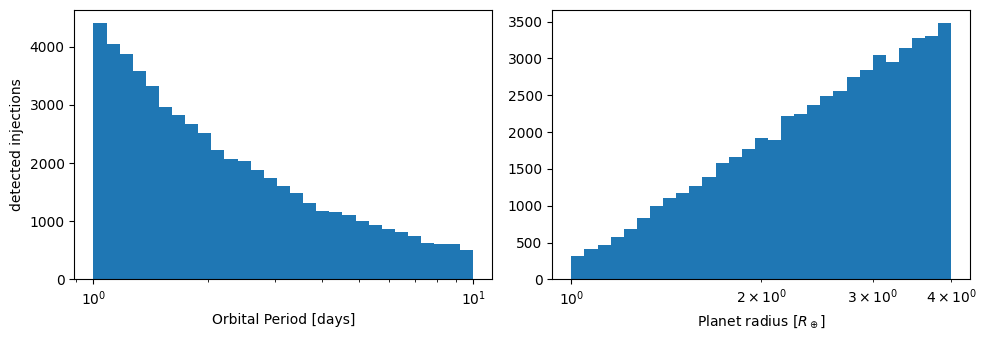

In [65]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
ax[0].hist(np.exp(lnP_det), bins=np.logspace(np.log10(pMin), np.log10(pMax), 30))
ax[0].set_xscale('log')
ax[0].set_xlabel('Orbital Period [days]')
ax[0].set_ylabel('detected injections')
ax[1].hist(np.exp(lnR_det), bins=np.logspace(np.log10(rMin), np.log10(rMax), 30))
ax[1].set_xscale('log'); ax[1].set_xlabel(r'Planet radius [$R_\oplus$]')
fig.tight_layout()
plt.show()

Each detected injection $j$ gets the weight

$$ w_j = \frac{\xi(\theta_j)}{p_{\rm draw}(\theta_j)} = 10^{cZ_j}\,h(P_j,R_j)\times N_\star\,\Delta\ln P\,\Delta\ln R . $$

* Eq. 8: $\mu = \frac{1}{N_{\rm draw}}\sum_{j\in{\rm det}} w_j$, so $\Lambda=\eta\,\mu$. The sum runs over detected
  injections only, but it is divided by **all** draws.
* Eq. 9: $\sigma^2 = \frac{1}{N_{\rm draw}^2}\sum_{j\in{\rm det}} w_j^2 - \frac{\mu^2}{N_{\rm draw}}$, and
  $N_{\rm eff}=\mu^2/\sigma^2$.
* Eq. 11: marginalizing over the Monte Carlo uncertainty replaces $e^{-\Lambda}$ with
  $\exp\!\left[\dfrac{\eta\mu\,(\eta\mu-2N_{\rm eff})}{2N_{\rm eff}}\right] = \exp\!\left[-\Lambda+\dfrac{\Lambda^2}{2N_{\rm eff}}\right]$.
* reject parameter values with $N_{\rm eff}\le 4N_{\rm obs}$.

In [67]:
def mu_neff(w):
    # w = weights of the DETECTED injections; Ndraw = ALL injections
    mu = np.sum(w) / Ndraw                                   # eq 8
    sigma2 = np.sum(w * w) / Ndraw**2 - mu**2 / Ndraw         # eq 9
    Neff = mu**2 / sigma2 if sigma2 > 0 else np.inf
    return mu, Neff

log10 = np.log(10.0)
lnP_obs, lnR_obs = np.log(P), np.log(R)

$$
\ln L = N_{\rm obs}\ln\eta + \sum_i\Big[c\ln 10\,Z_{s_i} + \ln h(P_i,R_i)\Big] - \eta\mu + \frac{(\eta\mu)^2}{2N_{\rm eff}}
$$

The $\sum_i$ term is the planet_term, and the last two terms are Farr's eq. 11.
The detection probabilities of the observed planets would multiply $L$ too, but they do not depend on the parameters,
so they drop out as a constant.

In [68]:
def lnprior(theta):
    log_eta, log_Pbr, a1, a2, b, c = theta
    if not (np.log(1e-4) < log_eta < np.log(10.0)):
        return -np.inf
    if not (lnPmin < log_Pbr < lnPmax):
        return -np.inf
    if np.any(np.abs([a1, a2, b, c]) > 15):
        return -np.inf
    return (norm.logpdf(a1, 2.0, 5.0) + norm.logpdf(a2, 0.6, 5.0) +
            norm.logpdf(b, -1.0, 5.0) + norm.logpdf(c, 0.0, 5.0))

def log_prob(theta):
    lp = lnprior(theta)
    if not np.isfinite(lp):
        return (-np.inf, np.nan)
    log_eta, log_Pbr, a1, a2, b, c = theta
    eta = np.exp(log_eta)

    # planet term: sum over detected planets of log[eta * 10^(cZ) * h] 
    planet_term = (Nobs * log_eta + c * log10 * np.sum(FeH_host)
                   + np.sum(log_shape(lnP_obs, lnR_obs, log_Pbr, a1, a2, b)))

    # selection integral from Farr (2019) 
    w = np.exp(log_shape(lnP_det, lnR_det, log_Pbr, a1, a2, b) + c * log10 * Z_det) * inv_pdraw
    mu, Neff = mu_neff(w)                              # eqs 8, 9
    if not (Neff > 4 * Nobs):                              
        return (-np.inf, Neff)
    Lam = eta * mu
    correction = Lam * (Lam - 2.0 * Neff) / (2.0 * Neff)    # eq 11

    return (lp + planet_term + correction, Neff)

In [69]:
mu_flat, _ = mu_neff(np.exp(log_shape(lnP_det, lnR_det, np.log(10), 0, 0, 0)) * inv_pdraw)
eta_guess = Nobs / mu_flat        # "planets found / planets we could have found", for a flat shape

ndim = 6
nwalkers = 32
pos = np.zeros((nwalkers, ndim))

i = 0
while i < nwalkers:
    trial = np.array([np.log(eta_guess) + 0.2 * np.random.randn(),   # log_eta
                      np.log(10.0) + 0.2 * np.random.randn(),         # log_Pbr
                      1.5 + 0.3 * np.random.randn(),                  # a1 (period slope below break)
                      0.0 + 0.3 * np.random.randn(),                  # a2 (period slope above break)
                      -1.5 + 0.3 * np.random.randn(),                 # b  (radius slope)
                      0.5 + 0.3 * np.random.randn()])                 # c  (metallicity slope)
    if np.isfinite(log_prob(trial)[0]):
        pos[i] = trial
        i += 1
eta_guess

/var/folders/6b/q0ls5s7570d8s04fbvw5gmxw0000gn/T/ipykernel_44700/369096708.py:9: RuntimeWarning: divide by zero encountered in log
  return a * lo + np.log(width) + np.log(ratio)


0.05347126725638687

In [70]:
max_n = 10000
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_prob)
sampler.run_mcmc(pos, max_n, progress=True);

100%|██████████| 10000/10000 [02:27<00:00, 67.78it/s]


In [75]:
tau = sampler.get_autocorr_time(tol=0)

In [77]:
tau

array([118.72665883, 294.15184352, 144.28579196, 250.77883712,
       127.16557146, 118.39592066])

In [76]:
np.round(max_n / tau, 1)

array([84.2, 34. , 69.3, 39.9, 78.6, 84.5])

In [78]:
sampler.acceptance_fraction.mean()

0.357921875

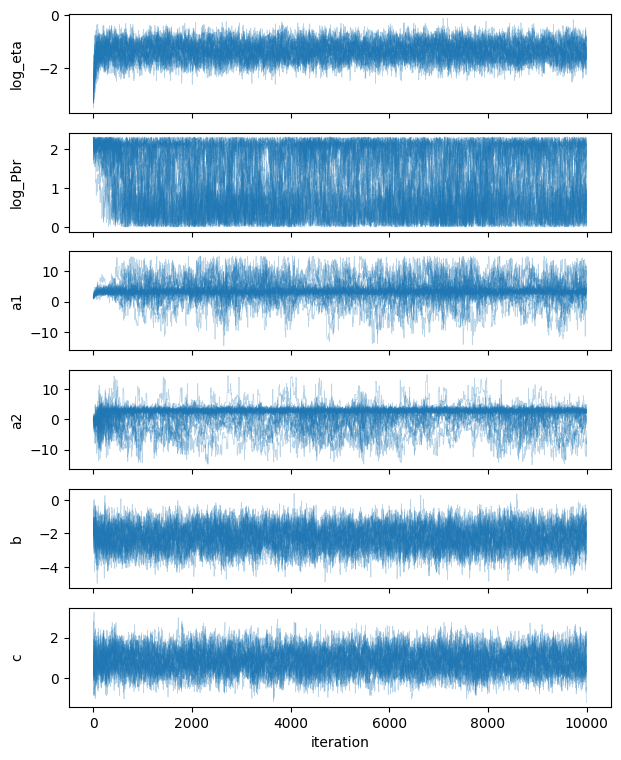

In [79]:
samples = sampler.get_chain()
labels = ['log_eta', 'log_Pbr', 'a1', 'a2', 'b', 'c']

fig, ax = plt.subplots(ndim, figsize=(7, 9), sharex=True)
for j in range(ndim):
    for k in range(nwalkers):
        ax[j].plot(samples[:, k, j], "C0-", lw=0.5, alpha=0.3)
    ax[j].set_ylabel(labels[j])
ax[-1].set_xlabel("iteration")
fig.align_ylabels(ax)
plt.show()

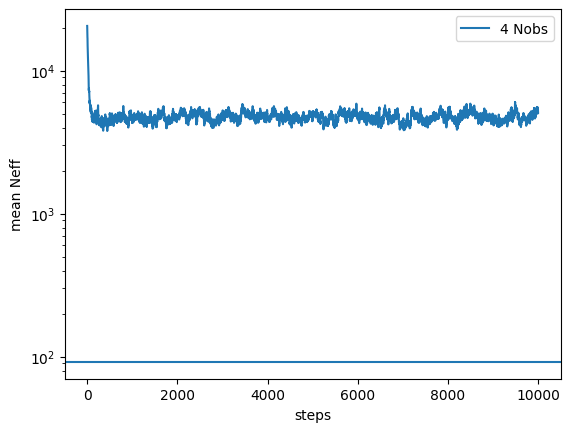

In [102]:
plt.plot(sampler.get_blobs().mean(axis=1))
plt.axhline(4 * Nobs, label='4 Nobs')
plt.xlabel('steps')
plt.ylabel('mean Neff')
plt.yscale('log')
plt.legend()
plt.show()

In [82]:
burn = int(10 * np.max(tau))
flat_samples = sampler.get_chain(discard=burn, flat=True)
Neff_samps = sampler.get_blobs(discard=burn, flat=True)
Neff_samps

array([3201.47954602, 5093.67698016, 4985.98412605, ..., 3190.08160828,
       4744.51774535, 4508.72083038])

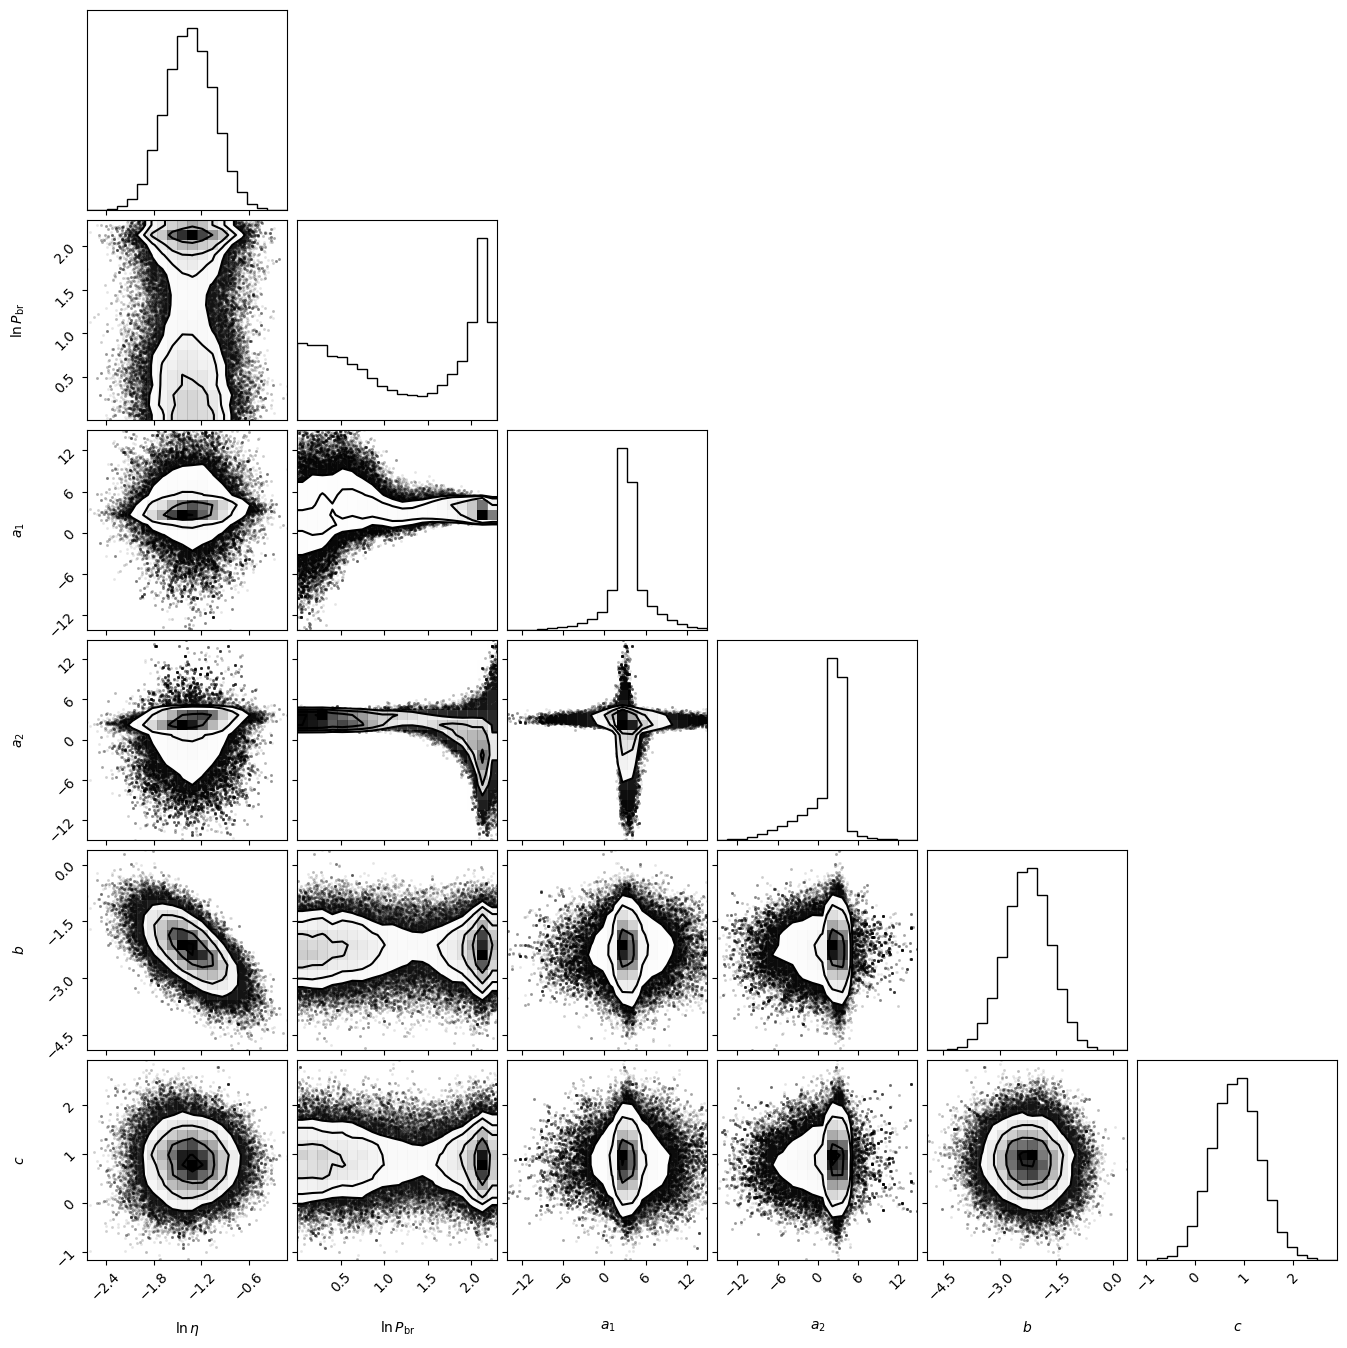

In [84]:
corner.corner(flat_samples, labels=[r'$\ln\eta$', r'$\ln P_{\rm br}$', r'$a_1$', r'$a_2$', r'$b$', r'$c$']);

In [85]:
q = np.percentile(flat_samples, [16, 50, 84], axis=0)
summary = pd.DataFrame(q.T, index=labels, columns=['q16', 'median', 'q84'])
summary.loc['eta'] = np.exp(q[:, 0])
summary.loc['Pbr [d]'] = np.exp(q[:, 1])
print('P(c > 0) =', np.mean(flat_samples[:, 5] > 0))
summary

P(c > 0) = 0.9602015157954384


,q16,median,q84
log_eta,-1.648111,-1.342931,-1.043274
log_Pbr,0.287151,1.268315,2.126886
a1,1.796416,3.290567,5.300607
a2,-1.382735,2.608359,3.413420
b,-2.838253,-2.239135,-1.647125
c,0.362699,0.852508,1.332119
eta,0.192413,0.261079,0.352299
Pbr [d],1.332625,3.554859,8.388700


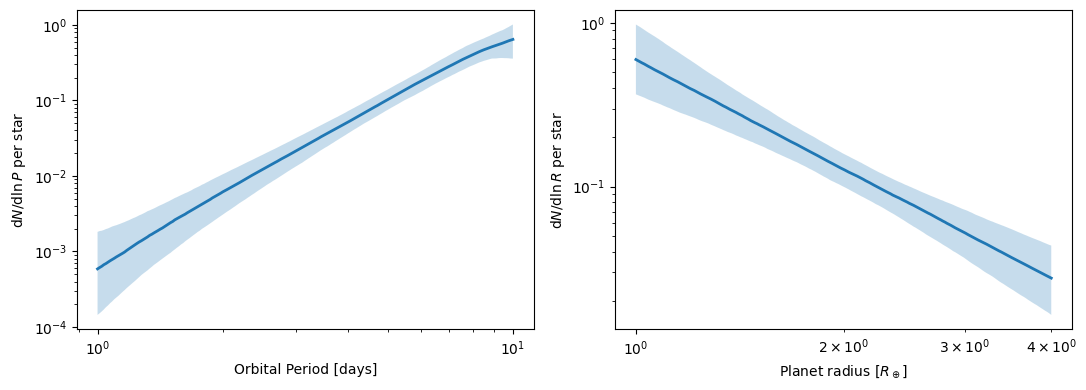

In [88]:
idx = np.random.choice(len(flat_samples), 2000, replace=False)
P_plot = np.logspace(np.log10(pMin), np.log10(pMax), 200)
R_plot = np.logspace(np.log10(rMin), np.log10(rMax), 200)

dNdlnP, dNdlnR = [], []
for log_eta, log_Pbr, a1, a2, b, c in flat_samples[idx]:
    # integrate h over lnR analytically -> period part only (and vice versa)
    x = np.log(P_plot) - log_Pbr
    log_normP = np.logaddexp(log_int_exp(lnPmin - log_Pbr, 0.0, a1), log_int_exp(0.0, lnPmax - log_Pbr, a2))
    dNdlnP.append(np.exp(log_eta + np.where(x < 0, a1 * x, a2 * x) - log_normP))
    dNdlnR.append(np.exp(log_eta + b * np.log(R_plot) - log_int_exp(lnRmin, lnRmax, b)))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for a_, grid, arr, obs, lab in [(ax[0], P_plot, np.array(dNdlnP), P, 'Orbital Period [days]'),
                                (ax[1], R_plot, np.array(dNdlnR), R, r'Planet radius [$R_\oplus$]')]:
    lo_, med_, hi_ = np.percentile(arr, [16, 50, 84], axis=0)
    a_.fill_between(grid, lo_, hi_, alpha=0.25)
    a_.plot(grid, med_, lw=2)
    # a_.plot(obs, np.full(len(obs), lo_.min() * 0.7), '|', color='red', ms=12)
    a_.set_xscale("log"); a_.set_yscale("log"); a_.set_xlabel(lab)
ax[0].set_ylabel(r"$\mathrm{d}N/\mathrm{d}\ln P$ per star")
ax[1].set_ylabel(r"$\mathrm{d}N/\mathrm{d}\ln R$ per star")
fig.tight_layout()
plt.show()

In [89]:
FeH_plot = np.linspace(FeHMin, FeHMax, 200)
curve = np.array([np.exp(s[0]) * 10**(s[5] * FeH_plot) for s in flat_samples[idx]])
lo, med, hi = np.percentile(curve, [16, 50, 84], axis=0)
curve.shape

(2000, 200)

In [91]:
a0, b0 = 0.5, 0.01
counts_obs = np.bincount(planet_bin, minlength=nbins)

def lnprior_bins(theta):
    log_Pbr, a1, a2, b = theta[:4]
    log_f = theta[4:]
    if not (lnPmin < log_Pbr < lnPmax):
        return -np.inf
    if np.any(np.abs([a1, a2, b]) > 15) or np.any(log_f < np.log(1e-6)) or np.any(log_f > np.log(10.0)):
        return -np.inf
    shape_prior = norm.logpdf(a1, 2.0, 5.0) + norm.logpdf(a2, 0.6, 5.0) + norm.logpdf(b, -1.0, 5.0)
    rate_prior = np.sum(a0 * log_f - b0 * np.exp(log_f))
    return shape_prior + rate_prior

def log_prob_bins(theta):
    lp = lnprior_bins(theta)
    if not np.isfinite(lp):
        return (-np.inf, np.nan)
    log_Pbr, a1, a2, b = theta[:4]
    log_f = np.asarray(theta[4:])

    planet_term = np.sum(counts_obs * log_f) + np.sum(log_shape(lnP_obs, lnR_obs, log_Pbr, a1, a2, b))

    w = np.exp(log_shape(lnP_det, lnR_det, log_Pbr, a1, a2, b) + log_f[bin_det]) * inv_pdraw
    Lam, Neff = mu_neff(w)               # here mu already includes the rates, so Lambda = mu
    if not (Neff > 4 * Nobs):
        return (-np.inf, Neff)
    correction = Lam * (Lam - 2.0 * Neff) / (2.0 * Neff)

    return (lp + planet_term + correction, Neff)

In [92]:
ndim_b = 4 + nbins
pos_b = np.zeros((nwalkers, ndim_b))
start = np.median(flat_samples, axis=0)
i = 0
while i < nwalkers:
    trial = np.concatenate([start[1:5] + 0.1 * np.random.randn(4),
                            np.log(eta_guess) + 0.2 * np.random.randn(nbins)])
    if np.isfinite(log_prob_bins(trial)[0]):
        pos_b[i] = trial
        i += 1

sampler_b = emcee.EnsembleSampler(nwalkers, ndim_b, log_prob_bins)
sampler_b.run_mcmc(pos_b, max_n, progress=True)

100%|██████████| 10000/10000 [02:34<00:00, 64.73it/s]


State([[ 2.08834243  3.16137463 -2.64769263 -2.18166153 -1.17653672 -0.753598
  -1.79965752]
 [ 0.28422223 -0.39857445  3.12637746 -2.16658317 -0.9671289  -1.20395345
  -0.85300171]
 [ 0.83078983  8.04779087  2.64481349 -2.73123648 -1.94636809 -0.61175543
  -0.77978822]
 [ 1.72440414  3.75555226 -0.07499939 -2.64952001 -2.2738516  -0.88966787
  -1.19522883]
 [ 1.53974875  2.97674401  2.80518443 -2.08794754 -3.06800656 -1.44817166
  -1.09221777]
 [ 0.0752954  12.26776049  2.58968553 -2.09139271 -2.3525905  -1.18618281
  -1.03168865]
 [ 2.15523543  3.16427779 -8.06737029 -1.58742182 -2.1507907  -1.83038822
  -1.62768638]
 [ 0.99232921  4.13183842  2.66631143 -3.99199477 -1.40788966 -0.73097494
  -0.41218619]
 [ 2.0670875   3.17063198 -5.27569707 -1.40722402 -2.65254323 -1.43621291
  -1.52483332]
 [ 0.04685783  0.49535005  2.36230179 -2.11745411 -1.90509158 -1.41335258
  -1.86728578]
 [ 0.13148837  2.23403182  3.33640177 -3.11806252 -1.67419893 -0.74765278
  -1.72919524]
 [ 2.15339178  3.

In [94]:
tau_b = sampler_b.get_autocorr_time(tol=0)
tau_b

array([353.93980114, 154.73074999, 279.08131252, 132.79427561,
       135.92289699, 134.11903934, 133.19521817])

In [95]:
max_n / tau_b

array([28.25339215, 64.62839481, 35.83185097, 75.30445084, 73.57112173,
       74.56062949, 75.07777034])

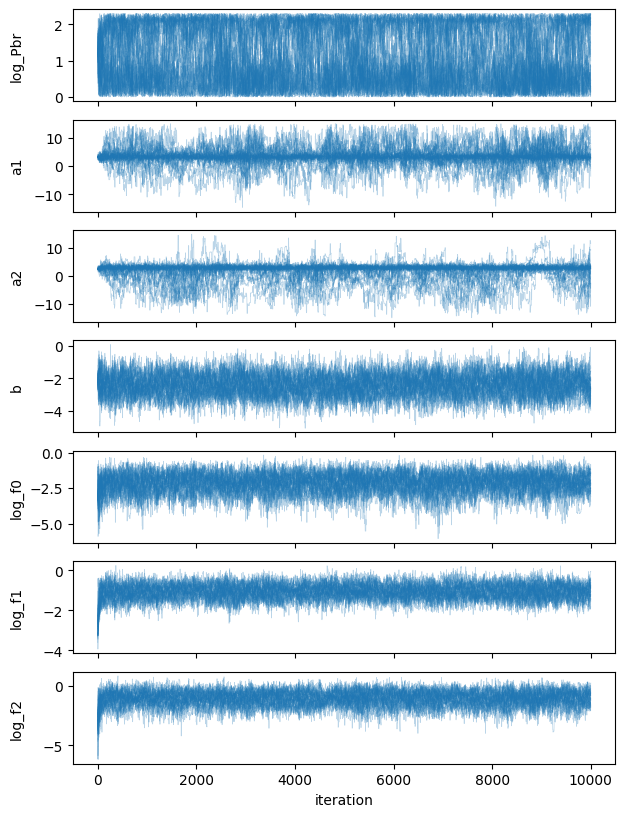

In [96]:
labels_b = ['log_Pbr', 'a1', 'a2', 'b'] + ['log_f%d' % k for k in range(nbins)]
samples_b = sampler_b.get_chain()
fig, ax = plt.subplots(ndim_b, figsize=(7, 1.4 * ndim_b), sharex=True)
for j in range(ndim_b):
    for k in range(nwalkers):
        ax[j].plot(samples_b[:, k, j], "C0-", lw=0.5, alpha=0.3)
    ax[j].set_ylabel(labels_b[j])
ax[-1].set_xlabel("iteration")
fig.align_ylabels(ax)
plt.show()

In [99]:
burn_b = int(10 * np.max(tau_b))
thin_b = max(1, int(0.5 * np.min(tau_b)))
flat_b = sampler_b.get_chain(discard=burn_b, thin=thin_b, flat=True)
Neff_b = sampler_b.get_blobs(discard=burn_b, thin=thin_b, flat=True)

f_bins = np.exp(flat_b[:, 4:])
bin_q16, bin_med, bin_q84 = np.percentile(f_bins, [16, 50, 84], axis=0)

bins = pd.DataFrame({'FeH_low': FeH_edges[:-1], 'FeH_high': FeH_edges[1:], 'stars': star_counts,
                     'planets': counts_obs, 'q16': bin_q16, 'median': bin_med, 'q84': bin_q84})
bins

,FeH_low,FeH_high,stars,planets,q16,median,q84
0,-0.50,-0.15,6375,3,0.067043,0.127406,0.219946
1,-0.15,0.15,7455,16,0.252236,0.351749,0.479838
2,0.15,0.50,1896,4,0.201884,0.361784,0.603348


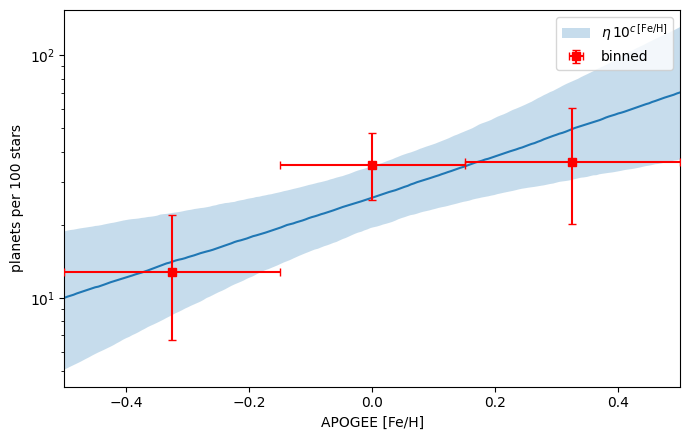

In [103]:
centers = 0.5 * (FeH_edges[:-1] + FeH_edges[1:])
half = 0.5 * np.diff(FeH_edges)
has = counts_obs > 0

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.fill_between(FeH_plot, 100 * lo, 100 * hi, alpha=0.25, label=r'$\eta\,10^{c\,[\mathrm{Fe/H}]}$')
ax.plot(FeH_plot, 100 * med)

ax.errorbar(centers[has], 100 * bin_med[has], xerr=half[has],
            yerr=[100 * (bin_med - bin_q16)[has], 100 * (bin_q84 - bin_med)[has]],
            fmt="s", color="red", capsize=3, zorder=5, label=r'binned')

ax.set_yscale("log")
ax.set_xlim(FeHMin, FeHMax)
ax.set_xlabel("APOGEE [Fe/H]")
ax.set_ylabel("planets per 100 stars")
ax.legend()
fig.tight_layout()
plt.show()